# Dissipation FTRL dynamics

This notebook provides a simple demonstration for solving the DFTRL dynamics given in Section 5 in the paper "The Hamiltonian of Poly-Matrix Zero-sum Games," [arXiv:2505.xxxxx]().

For the details on the theoretical aspects, see Section 4 of the paper.

In [ ]:
#!pip install torchdiffeq
#!pip show torchdiffeq
#!sed -i -e '34i \            if i%1000==0: print(f"t={i}")' /path/to/torchdiffeq/_impl/solvers.py
#!cat /path/to/torchdiffeq/_impl/solvers.py

%cd /path/to/dftrl
#!ls -la

In [4]:
import random
import numpy as np
import torch

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

!python dftrl.py -h

usage: dftrl.py [-h] [--n_players N_PLAYERS] [--n_actions N_ACTIONS]
                [--regularizer {entropic,euclidean}] [--epsilon EPSILON]
                [--initial_payoff INITIAL_PAYOFF]

options:
  -h, --help            show this help message and exit
  --n_players N_PLAYERS
                        Number of players (default: 2)
  --n_actions N_ACTIONS
                        Number of actions (default: 2)
  --regularizer {entropic,euclidean}
                        Type of regularizer function h (default: "entropic")
  --epsilon EPSILON     Dissipation parameter, assumed to be 0 or positive
                        real number (default: 0.1)
  --initial_payoff INITIAL_PAYOFF
                        Apply an adjustment to the initial state (default:
                        None)


t=1000
t=2000
t=3000
t=4000
t=5000
t=6000
t=7000
t=8000
t=9000
Total time steps (Tmax/dt) = 10000, 2*n_players*n_actions: 12

 trajectory of x1sol:
tensor([[0.4105, 0.4383, 0.1512],
        [0.4124, 0.4372, 0.1504],
        [0.4142, 0.4361, 0.1497],
        [0.4161, 0.4350, 0.1490],
        [0.4179, 0.4338, 0.1482],
        [0.4198, 0.4327, 0.1475],
        [0.4217, 0.4315, 0.1468],
        [0.4236, 0.4303, 0.1460],
        [0.4255, 0.4291, 0.1453],
        [0.4275, 0.4279, 0.1446]])
 ...
tensor([[0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667],
        [0.5000, 0.3333, 0.1667]])

 trajectory of x2sol:
tensor([[0.5528, 0.1772, 0.2700],
        [0.5518, 0.1771, 0.2710],
        [0.5509, 0.1771, 0.2721],
        [0.5499, 0.1770, 0.2731],
      

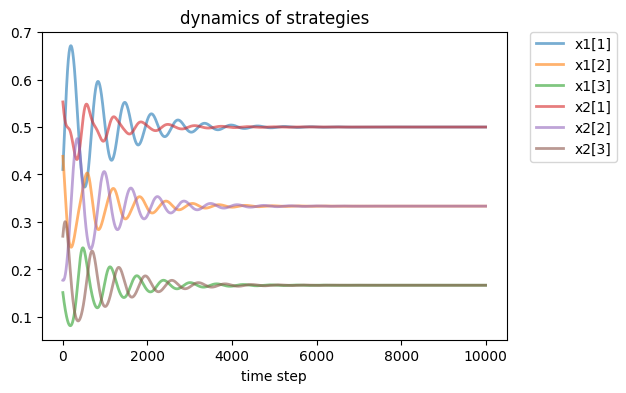

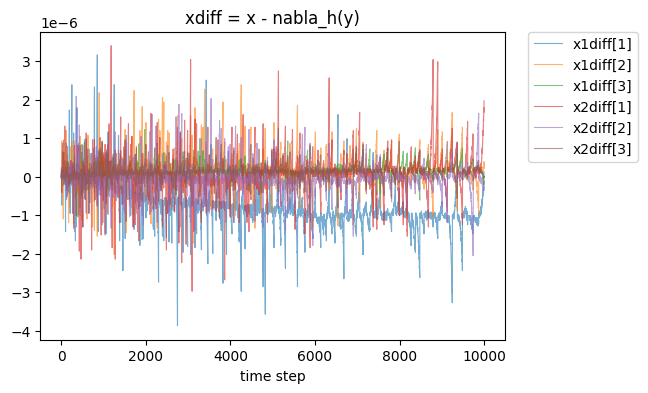

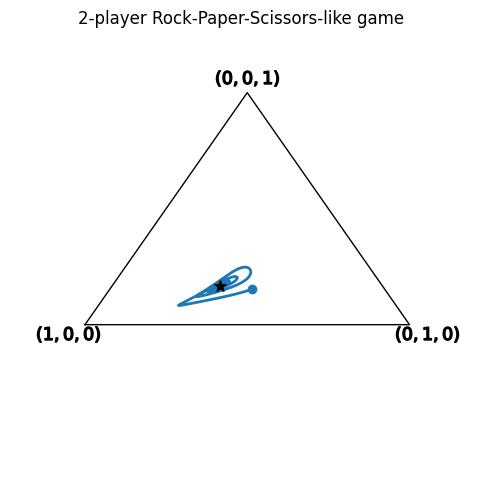

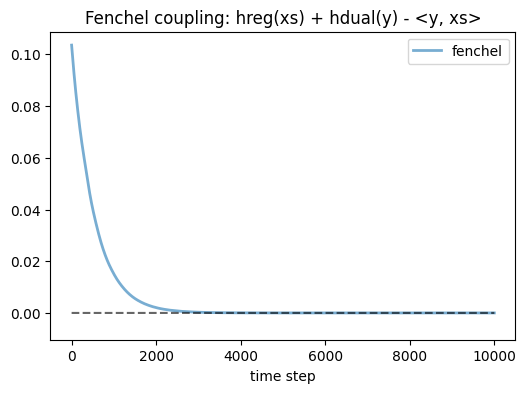

In [4]:
# a minimal demo
# two-player Rock-Paper-Scissors

from dataclasses import dataclass
import dftrl

@dataclass
class DFTRLArgs:
    n_players: int = 2
    n_actions: int = 3
    regularizer: str = 'entropic'
    epsilon: float = 0.1
    initial_payoff = 'rand'

dftrl.main(args=DFTRLArgs)

t=1000
t=2000
t=3000
t=4000
t=5000
t=6000
t=7000
t=8000
t=9000
Total time steps (Tmax/dt) = 10000, 2*n_players*n_actions: 12

 trajectory of x1sol:
tensor([[0.2546, 0.7454],
        [0.2572, 0.7428],
        [0.2598, 0.7402],
        [0.2625, 0.7375],
        [0.2654, 0.7346],
        [0.2683, 0.7317],
        [0.2714, 0.7286],
        [0.2745, 0.7255],
        [0.2777, 0.7223],
        [0.2811, 0.7189]])
 ...
tensor([[0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995],
        [0.6005, 0.3995]])

 trajectory of x2sol:
tensor([[0.8341, 0.1659],
        [0.8364, 0.1636],
        [0.8385, 0.1615],
        [0.8405, 0.1595],
        [0.8425, 0.1575],
        [0.8443, 0.1557],
        [0.8461, 0.1539],
        [0.8477, 0.1523],
        [0.8493, 0.1507],
        [0.8508, 0.1492]])
 ...
tensor([[0.6005, 0.3995],
        [0

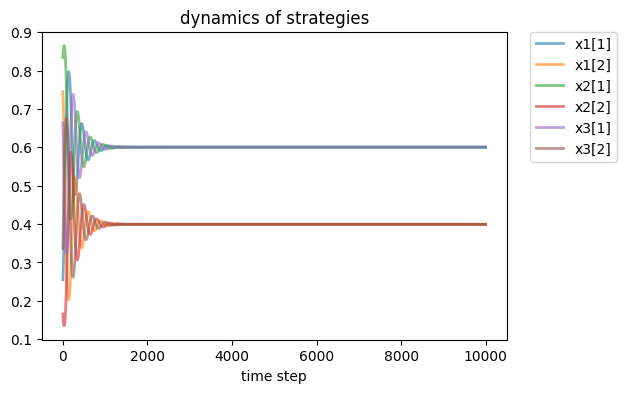

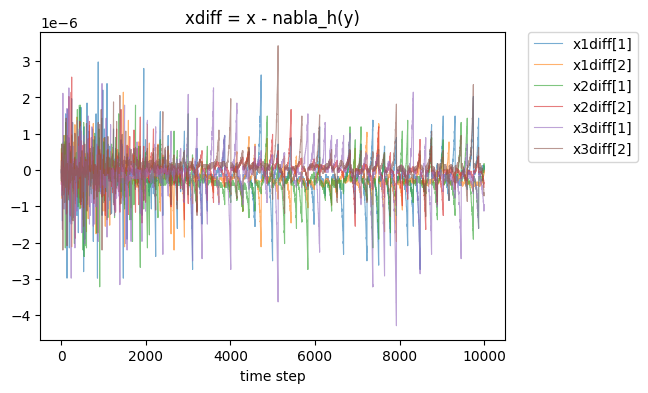

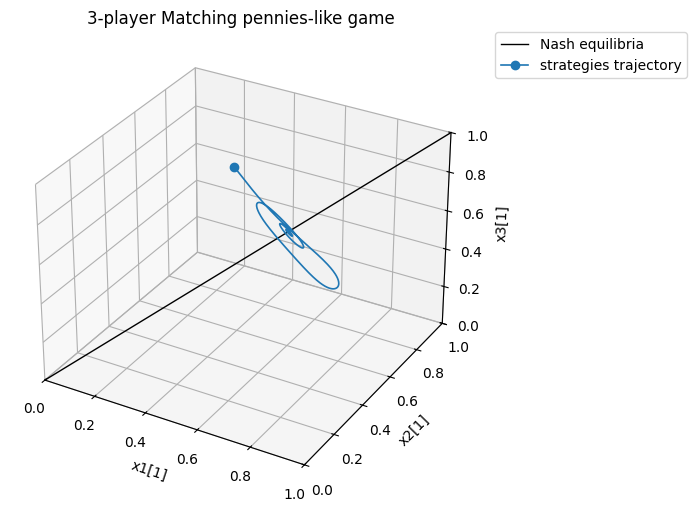

In [5]:
# a more explicit demo
# three-player Matching Pennies

from dataclasses import dataclass
from dftrl import payoffmat_nasheq, run_game, plot_x, plot_xdiff, plot_x3d, plot_xsimplex, plot_fenchel

@dataclass
class DFTRLArgs:
    n_players: int = 3
    n_actions: int = 2
    regularizer: str = 'entropic'
    epsilon: float = 0.1
    initial_payoff = 'rand'

def main(args):
    #* (1/3): Define a game
    A, xs = payoffmat_nasheq(args.n_actions)

    #* (2/3): Run the game
    sol_split = run_game(
        args.n_players,
        args.n_actions,
        A,
        args.regularizer,
        args.epsilon,
        args.initial_payoff,  # if 'rand' or 'randn', apply a random adjustment to the initial state.
        )
    print('\n trajectory of x1sol:', sol_split[0][:10], ' ...', sol_split[0][-10:], sep='\n')
    print('\n trajectory of x2sol:', sol_split[1][:10], ' ...', sol_split[1][-10:], sep='\n')
    if args.n_players==3: print('\n trajectory of x3sol:', sol_split[2][:10], ' ...', sol_split[2][-10:], sep='\n')

    #* (3/3): Plot the results
    plot_x(sol_split, args.n_players, args.n_actions)
    plot_xdiff(sol_split, args.n_players, args.n_actions, args.regularizer)
    if args.n_players==3 and args.n_actions==2:
        plot_x3d(sol_split)
    elif args.n_players==2 and args.n_actions==3:
        plot_xsimplex(sol_split, xs)
        plot_fenchel(sol_split, xs, args.n_players, args.regularizer)
    else:
        plot_fenchel(sol_split, xs, args.n_players, args.regularizer)


main(args=DFTRLArgs)